<a href="https://colab.research.google.com/github/Abhhiiissshhek/100_days_of_ML_challenge/blob/main/day-21-feature-importance/day21_feature_importance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Day 21**

# **Feature Importance**

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

#Titanic Dataset Loading !!
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

#Features
X = df[['Pclass','Age','Fare','SibSp','Parch']].copy()
y = df['Survived']

#missing value handling in age column using medain !
X['Age'] = X['Age'].fillna(X['Age'].median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#using Randomforest model
model = RandomForestClassifier()

# applying GridsearchCV
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10]
}

grid = GridSearchCV(model, param_grid, cv=5)

grid.fit(X_train, y_train)



GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [3, 5, 10],
                         'n_estimators': [50, 100, 200]})

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# Train model
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# Extract feature importance
importance = model.feature_importances_

feature_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_imp)

  Feature  Importance
2    Fare    0.426569
1     Age    0.378995
0  Pclass    0.084300
3   SibSp    0.063630
4   Parch    0.046505


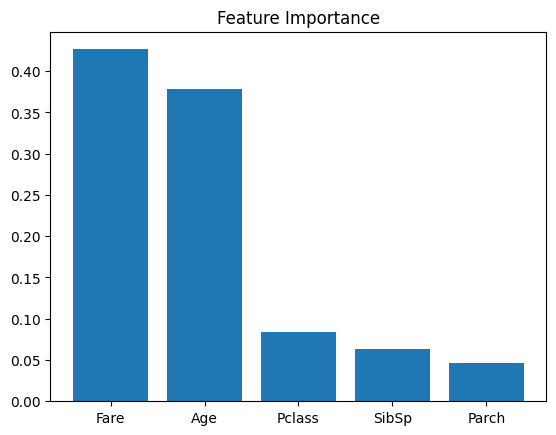

In [10]:
plt.bar(feature_imp["Feature"], feature_imp["Importance"])
plt.title("Feature Importance")
plt.show()

# **Features in Titanic Dataset :**

* Age

* Fare

* Passenger Class

* SibSp

* Parch